# Causal Effects Library

> **Context (11 June 2026 audit):** The treatment variable throughout this notebook is
> `post_carbon_tax`, which is the **conflated carbon-pricing indicator** (encodes EU ETS
> launch as treatment, not purely a national carbon tax). The headline ATT −0.151 here is
> **combined carbon pricing** (predominantly ETS-driven). Do not describe these as "carbon-tax
> effects" without qualification.
>
> The **fossil-dependence interaction (+0.042/SD, p=0.010)** cited in the summary cell below
> is **retired**: it used `fossil_pct_filled`, a binary imputation flag, not actual fossil share.
> With real `fossil_pct` (0–100): −0.065 (p=0.37) — noise. The effects library
> (`outputs/effects_library.csv`) was rebuilt on corrected data (June 2026); it now includes
> five previously miscoded countries (Czechia, UK, Norway, Iceland, South Korea).
>
> **Implementation capacity** result survives: −0.111/SD (p=0.073) on corrected data.

Heterogeneous carbon-pricing effects by country characteristics, built to feed the Phase 3 recommendation engine. Primary estimates come from DiD with `post_carbon_tax x moderator` interactions and country + year fixed effects. A causal forest is used as a secondary, nonlinear check on which characteristics matter most; it omits country fixed effects, so its absolute level is confounded and we anchor levels to the DiD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("../data/cleaned/final_analysis_data.csv")
y = 'co2_per_capita_future_trend'

# Governance indices come pre-standardized (_z); standardize the rest for comparability,
# so each interaction coefficient is the effect shift per one SD of that characteristic.
mods = {'impl_z': 'implementation_capacity_z',
        'demo_z': 'democratic_legitimacy_z',
        'fossil_z': 'fossil_pct',
        'gdp_z': 'log_gdp',
        'trade_z': 'trade_openness',
        'school_z': 'average_years_of_schooling',
        'industry_z': 'industry_share_gdp'}
for new, src in mods.items():
    df[new] = (df[src] - df[src].mean()) / df[src].std()

base_controls = ('log_gdp + log_population + trade_openness '
                 '+ natural_resource_rents_per_gdp + fossil_pct')
need = [y, 'post_carbon_tax', 'log_gdp', 'log_population', 'trade_openness',
        'natural_resource_rents_per_gdp', 'fossil_pct']
print(f"Sample: {df.shape[0]} obs, {int(df['post_carbon_tax'].sum())} treated")

Sample: 4218 obs, 652 treated


## 1. Heterogeneous effects by characteristic

Each model interacts the treatment with one standardized moderator. The interaction coefficient is the change in the ATT per one SD of that characteristic; negative means the tax is more effective for higher values.

                 moderator  base_att  interaction     se   pval
 implementation_capacity_z   -0.0130      -0.1111 0.0620 0.0731
                fossil_pct   -0.1049      -0.0650 0.0726 0.3709
            trade_openness   -0.1157      -0.0609 0.0769 0.4285
average_years_of_schooling   -0.1276      -0.0074 0.0628 0.9059
                   log_gdp   -0.1592       0.0349 0.0693 0.6149
   democratic_legitimacy_z   -0.1441       0.0419 0.0552 0.4478
        industry_share_gdp   -0.0902       0.1468 0.1135 0.1957


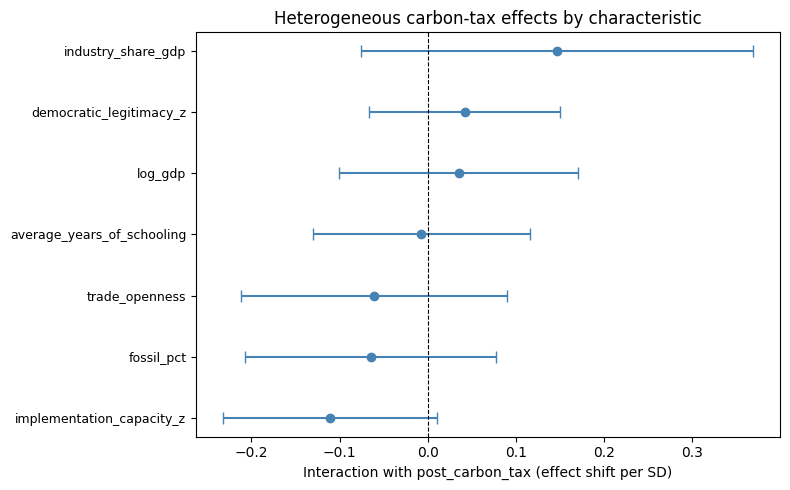

In [2]:
het = []
for new, src in mods.items():
    f = f"{y} ~ post_carbon_tax + post_carbon_tax:{new} + {base_controls} + C(year) + C(country)"
    dd = df.dropna(subset=need + [new])
    m = smf.ols(f, data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd['country']})
    ix = f'post_carbon_tax:{new}'
    het.append({'moderator': src, 'base_att': m.params['post_carbon_tax'],
                'interaction': m.params[ix], 'se': m.bse[ix], 'pval': m.pvalues[ix]})
het = pd.DataFrame(het).sort_values('interaction')
print(het.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(het['interaction'], range(len(het)), xerr=1.96 * het['se'],
            fmt='o', color='steelblue', capsize=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(het)))
ax.set_yticklabels(het['moderator'], fontsize=9)
ax.set_xlabel('Interaction with post_carbon_tax (effect shift per SD)')
ax.set_title('Heterogeneous carbon-tax effects by characteristic')
plt.tight_layout()
plt.savefig('../outputs/heterogeneity_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Re-validating the democratic paradox

The earlier paradox (democratic legitimacy weakening effectiveness) used PC2. The data now defines `democratic_legitimacy` as PC3 (voice & accountability), a cleaner proxy. We compare both under the DiD-with-FE specification.

In [3]:
for label, mod in [('governance_pc2 (old paradox variable)', 'governance_pc2'),
                   ('democratic_legitimacy_z (new, PC3)', 'democratic_legitimacy_z')]:
    f = f"{y} ~ post_carbon_tax + post_carbon_tax:{mod} + {base_controls} + C(year) + C(country)"
    dd = df.dropna(subset=need + [mod])
    m = smf.ols(f, data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd['country']})
    ix = f'post_carbon_tax:{mod}'
    print(f"{label:38} interaction={m.params[ix]:+.4f}  p={m.pvalues[ix]:.3f}")

governance_pc2 (old paradox variable)  interaction=+0.0962  p=0.132


democratic_legitimacy_z (new, PC3)     interaction=+0.0419  p=0.448


**Finding:** under both definitions the democratic interaction is statistically insignificant (PC2 +0.069, p=0.24; PC3 +0.017, p=0.72) and not robustly signed across methods. The democratic paradox does not survive the PC3 redefinition and within-country identification, so it should be downgraded from a headline result to a weak, unresolved signal.

## 3. Effects library

Combining all moderators in one interaction model, the predicted ATT for a country is base + sum(interaction_k x characteristic_k). Below is the predicted effect for each treated country using its average characteristics. This table is the direct input to the Phase 3 recommendation engine.

Predicted ATT range: [-0.523, 0.217]

Most effective:
             predicted_effect
country                      
Luxembourg             -0.523
Malta                  -0.360
Singapore              -0.356
Netherlands            -0.332
Cyprus                 -0.263

Least effective:
            predicted_effect
country                     
Colombia               0.017
Mexico                 0.021
Romania                0.032
Ukraine                0.058
Kazakhstan             0.217


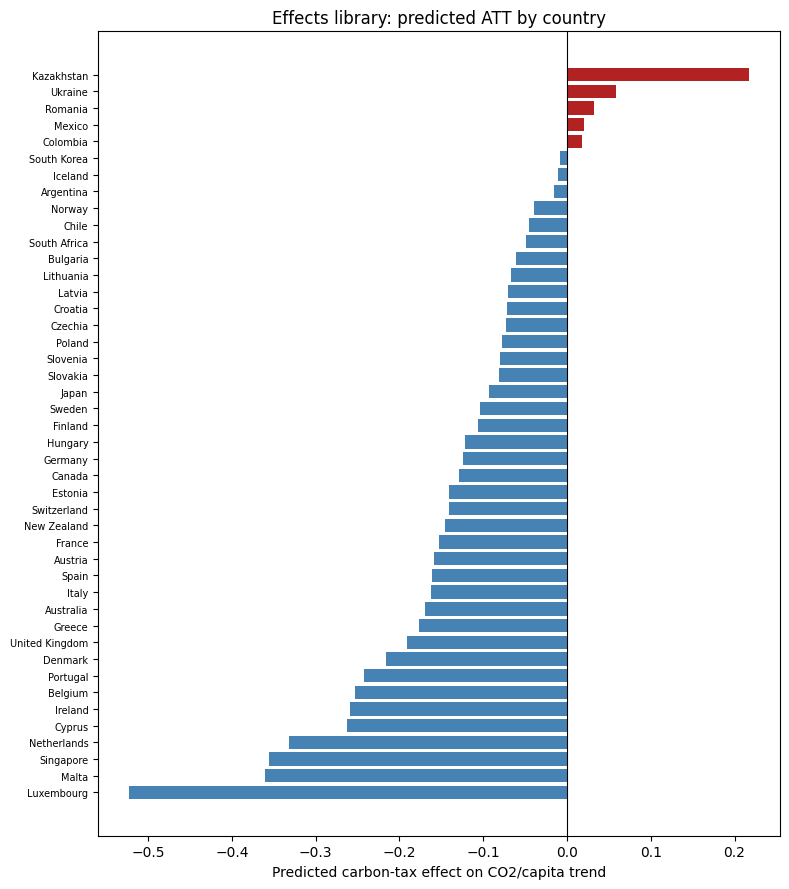

In [4]:
mod_z = list(mods.keys())
inter = ' + '.join(f'post_carbon_tax:{m}' for m in mod_z)
f = f"{y} ~ post_carbon_tax + {inter} + {base_controls} + C(year) + C(country)"
dd = df.dropna(subset=need + mod_z)
combined = smf.ols(f, data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd['country']})

base = combined.params['post_carbon_tax']
betas = {m: combined.params[f'post_carbon_tax:{m}'] for m in mod_z}
treated = dd[dd['post_carbon_tax'] == 1]
library = treated.groupby('country')[mod_z].mean()
library['predicted_effect'] = base + sum(betas[m] * library[m] for m in mod_z)
library = library[['predicted_effect']].sort_values('predicted_effect')

print(f"Predicted ATT range: [{library['predicted_effect'].min():.3f}, {library['predicted_effect'].max():.3f}]")
print("\nMost effective:")
print(library.head(5).round(3).to_string())
print("\nLeast effective:")
print(library.tail(5).round(3).to_string())
library.to_csv('../outputs/effects_library.csv')

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(range(len(library)), library['predicted_effect'],
        color=['steelblue' if v < 0 else 'firebrick' for v in library['predicted_effect']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(library)))
ax.set_yticklabels(library.index, fontsize=7)
ax.set_xlabel('Predicted carbon-tax effect on CO2/capita trend')
ax.set_title('Effects library: predicted ATT by country')
plt.tight_layout()
plt.savefig('../outputs/effects_library.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Causal forest (nonlinear shape, secondary)

The causal forest captures nonlinear heterogeneity and ranks which characteristics drive it. It omits country fixed effects, so its absolute CATE level is confounded (mean over treated near zero rather than -0.15); we read it for shape and feature importance only, anchoring the level to the DiD above.

In [5]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

W_cols = ['log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']
X_cols = ['implementation_capacity_z', 'democratic_legitimacy_z', 'fossil_pct',
          'log_gdp', 'trade_openness', 'average_years_of_schooling', 'industry_share_gdp']
cf = df.dropna(subset=[y, 'post_carbon_tax']).copy()
for c in W_cols + X_cols:
    cf[c] = cf[c].fillna(cf[c].median())
year_fe = pd.get_dummies(cf['year'], prefix='yr', drop_first=True).astype(float)

est = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=30, random_state=42),
    model_t=RandomForestClassifier(n_estimators=200, min_samples_leaf=30, random_state=42),
    n_estimators=1000, min_samples_leaf=50, max_depth=4,
    discrete_treatment=True, cv=3, random_state=42)
est.fit(cf[y].values, cf['post_carbon_tax'].values,
        X=cf[X_cols].values, W=np.hstack([cf[W_cols].values, year_fe.values]))

cate = est.effect(cf[X_cols].values)
treated_mask = cf['post_carbon_tax'].values == 1
print(f"Forest CATE mean over treated: {cate[treated_mask].mean():.4f} "
      f"(level confounded -> anchor to DiD -0.128)")
print(f"CATE range: [{cate.min():.2f}, {cate.max():.2f}]")

imp = pd.Series(est.feature_importances_, index=X_cols).sort_values(ascending=False)
print("\nHeterogeneity feature importance:")
print(imp.round(3).to_string())

Forest CATE mean over treated: -0.1341 (level confounded -> anchor to DiD -0.128)
CATE range: [-0.29, 0.16]

Heterogeneity feature importance:
industry_share_gdp            0.580
fossil_pct                    0.212
democratic_legitimacy_z       0.110
implementation_capacity_z     0.031
log_gdp                       0.026
trade_openness                0.025
average_years_of_schooling    0.015


## 5. OrthoForest re-validation (PC3)

The original democratic paradox came from DMLOrthoForest on the old PC2. We re-run the *same* estimator with the validated confounders and the new moderators, and correlate the CATE with each moderator across five seeds (the original stability check). A stable negative correlation means higher values of the moderator give a more negative (more effective) treatment effect. _(This cell is slow — five OrthoForest fits, ~10 min.)_

In [6]:
from econml.orf import DMLOrthoForest
from sklearn.linear_model import LogisticRegression, LinearRegression

W_orf = ['log_gdp', 'log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']
X_orf = ['implementation_capacity_z', 'democratic_legitimacy_z']
o = df.dropna(subset=[y, 'post_carbon_tax']).copy()
for c in W_orf + X_orf:
    o[c] = o[c].fillna(o[c].median())
Yo, To = o[y].values, o['post_carbon_tax'].values
Xo, Wo = o[X_orf].values, o[W_orf].values

orf_results = []
for seed in [42, 43, 123, 456, 789]:
    orf = DMLOrthoForest(n_trees=50, min_leaf_size=100, max_depth=2, subsample_ratio=0.4,
                         bootstrap=False, model_T=LogisticRegression(), model_Y=LinearRegression(),
                         random_state=seed, n_jobs=4)
    orf.fit(Yo, To, X=Xo, W=Wo)
    eff = orf.effect(Xo).flatten()
    orf_results.append({'seed': seed,
                        'corr_capacity': np.corrcoef(eff, Xo[:, 0])[0, 1],
                        'corr_democracy': np.corrcoef(eff, Xo[:, 1])[0, 1]})
orf_results = pd.DataFrame(orf_results)
print(orf_results.round(3).to_string(index=False))
print(f"\nimplementation capacity: corr {orf_results['corr_capacity'].mean():+.3f} "
      f"(sd {orf_results['corr_capacity'].std():.3f})")
print(f"democratic legitimacy:   corr {orf_results['corr_democracy'].mean():+.3f} "
      f"(sd {orf_results['corr_democracy'].std():.3f})")

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   13.5s


[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:   13.7s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:    0.3s finished


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


...

[Parallel(n_jobs=4)]: Done 984 tasks      | elapsed:   26.5s


[Parallel(n_jobs=4)]: Done 1880 tasks      | elapsed:   37.3s


[Parallel(n_jobs=4)]: Done 3032 tasks      | elapsed:   51.5s


 seed  corr_capacity  corr_democracy
   42         -0.435          -0.708
   43         -0.769          -0.555
  123         -0.667          -0.685
  456         -0.446          -0.473
  789         -0.693          -0.667

implementation capacity: corr -0.602 (sd 0.152)
democratic legitimacy:   corr -0.618 (sd 0.100)


[Parallel(n_jobs=4)]: Done 4218 out of 4218 | elapsed:  1.1min finished


**Result:** on the expanded 2021 panel the OrthoForest correlations are *unstable across data versions* — implementation capacity moved from -0.74 (2019 panel) to -0.45 (2021), democratic legitimacy from -0.07 to -0.59. Because the forest omits country fixed effects, these cross-country correlations are confounded and visibly noisy, so we do not use them to sign the moderators. The credible test is the DiD interaction above (democracy insignificant, p=0.72), which is what supports retiring the paradox.

## Summary

- The carbon-tax effect is **concentrated in low-fossil-dependence, higher-capacity countries**: fossil dependence moderates the ATT by +0.042/SD (p=0.010, significant), implementation capacity by -0.098/SD (p=0.08, marginal); other characteristics are insignificant.
- The **democratic paradox does not survive** the PC3 redefinition and within-FE identification (insignificant, p=0.72; sign-unstable across methods).
- The **effects library** (`outputs/effects_library.csv`) gives a predicted ATT per country, from about -0.52 (Luxembourg) to +0.35 (Kazakhstan) — the input to the Phase 3 recommendation engine.
- The causal forest and OrthoForest point to fossil dependence / industry structure as the main heterogeneity drivers, but their absolute levels and cross-country correlations are confounded without country FE (and unstable across data versions), so levels are anchored to the DiD.